# Лабораторна робота № 1

## Вхідний аналіз набору даних

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Пригадати роботу в Jupyter Notebook, бібліотеці `pandas` та побудову графіків —
і зробити це не на навчальному прикладі, а на реальному файлі, який ніхто не готував
спеціально для вас.

Ця робота виконується **до першої лекції**. Нічого нового знати не потрібно: усе,
що знадобиться, ви вже проходили в попередніх курсах. Усі поняття, яких ви тут
торкнетеся мимохідь, отримають назви й пояснення на лекціях 3 і 4.

### Дані

Файл `20171129_FINAL_FINAL.xlsx`, аркуш `Sheet1` — спостереження космічної погоди
за 28 серпня — 22 вересня 2017 року, зібрані з трьох різних джерел.

Файл видається **як є**, рівно в тому вигляді, у якому його колись вивантажили.
Ніхто не приводив його до ладу, і саме в цьому сенс: справжні дані здебільшого
надходять саме такими.

### Що ви маєте зробити

| Етап | Зміст | Де |
|---|---|---|
| 1 | Розібратися, що взагалі лежить у файлі | аудиторно |
| 2 | Виділити три таблиці й привести їх до робочого вигляду | аудиторно |
| 3 | Скласти паспорт даних: що є, чого бракує, що виглядає дивно | аудиторно |
| 4 | Об'єднати три таблиці в одну | аудиторно |
| 5 | Побудувати п'ять графіків, кожен — відповідь на питання | аудиторно + самостійно |
| 6 | Порівняти два графіки одних і тих самих даних | самостійно |
| 7 | Записати три спостереження про дані | самостійно |
| 8 | Декларація про використання інструментів ШІ | самостійно |

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Ноутбук має виконуватися згори
   донизу на чистому ядрі** (Kernel → Restart & Run All) без помилок — це перевіряється
   першою дією на захисті.
2. Файл `master_hourly.csv` — об'єднана таблиця з етапу 4.
3. Експорт ноутбука у HTML або PDF.
4. Заповнена декларація (етап 8). Без неї фінальна самоперевірка не проходить.

### Критерії оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Дані не опрацьовано, графіки не побудовано або побудовано з грубими помилками |
| 1 | Таблиці прочитано й кілька графіків побудовано, але типи графіків не відповідають даним, дивних значень не помічено |
| 2 | Таблиці розібрано й об'єднано, графіки коректні та підписані, але висновків під ними немає або вони формальні |
| 4 | Усе вище виконано, знайдено й пояснено дивні значення, під кожним графіком є змістовний висновок про дані |

**Головне про оцінку:** бали ставляться не за наявність графіка, а за речення під ним.
Код, який нічого не пояснює, коштує двох балів з чотирьох.

---
## Нагадування про Jupyter

Якщо давно не працювали — три речі, які знадобляться сьогодні:

* `Shift+Enter` виконує клітинку, `Esc` `A` / `Esc` `B` додає клітинку вище / нижче,
  `Esc` `M` перетворює клітинку на текстову (Markdown), `Esc` `Y` — назад на код.
* **Порядок виконання має значення.** Якщо ви правили клітинки в довільному порядку,
  результат може залежати від історії запусків. Перед здачею обов'язково
  **Kernel → Restart & Run All** — так ви побачите ноутбук очима викладача.
* Текстові клітинки — не прикраса. Висновки пишуться в них, а не в коментарях до коду.

---
## Крок 0. Ваші дані та варіант

Заповніть три змінні й виконайте обидві клітинки. Друга надрукує **ваше
індивідуальне завдання** — воно відрізняється від завдання сусіда.

In [1]:
ПІБ = 'Костак Олеся'       
ГРУПА = 'ШІ-32'     
ВАРІАНТ = 6

assert ПІБ and ГРУПА and ВАРІАНТ, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ'

In [2]:
# --- клітинку не редагувати: вона видає ваше персональне завдання ------------
ПОТОКИ = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

ПАРИ = [('швидкість вітру', 'густина вітру'),
        ('швидкість вітру', 'потік P>10'),
        ('густина вітру', 'потік P>1'),
        ('радіопотік F10.7', 'потік P>10'),
        ('радіопотік F10.7', 'швидкість вітру'),
        ('потік E>0.8', 'потік P>10')]

АГРЕГАТИ = ['середнє', 'максимум', 'медіана', 'мінімум']

ПИТАННЯ = [
    'Скільки годин за все вікно ваш потік перевищував своє власне медіанне значення?',
    'У яку добу середнє значення вашого потоку було найбільшим? А найменшим?',
    'О котрій годині доби потік E>0.8 у середньому найбільший? Побудуйте графік середнього за годинами доби.',
    'Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?',
    'У який день радіопотік F10.7 був найбільшим і чи збігається цей день з піком вашого потоку?',
    'Порівняйте медіану вашого потоку за перший і за другий тиждень спостережень. У скільки разів вони відрізняються?',
    'Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?',
    'Який зі стовпців об’єднаної таблиці має найбільший розкид відносно власного середнього?',
    'Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?',
    'Скільки різних діб потрапило у групу «активні» і скільки — у групу «дуже активні»?',
]

i = int(ВАРІАНТ)
завдання = {
    'ваш потік':                      ПОТОКИ[(i * 3 + 1) % 8],
    'ваша пара для графіка 3':        ' та '.join(ПАРИ[(i * 5 + 2) % 6]),
    'ваш агрегат для етапу 4':        АГРЕГАТИ[(i * 5 + 1) % 4],
    'ваше додаткове питання':         ПИТАННЯ[(i * 11 + 5) % 10],
}

print('ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · %s, %s, варіант %d' % (ПІБ, ГРУПА, i))
print('=' * 78)
for k, v in завдання.items():
    print('%-28s %s' % (k + ':', v))

ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · Костак Олеся, ШІ-32, варіант 6
ваш потік:                   P>30
ваша пара для графіка 3:     густина вітру та потік P>1
ваш агрегат для етапу 4:     мінімум
ваше додаткове питання:      У яку добу середнє значення вашого потоку було найбільшим? А найменшим?


Далі за текстом **«ваш потік»** означає стовпець, названий у першому рядку завдання.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

ФАЙЛ = '20171129_FINAL_FINAL.xlsx'

---
# Етап 1. Що взагалі лежить у файлі

Перше правило роботи з незнайомими даними: спершу подивитися, потім рахувати.

### Завдання 1.1
Спробуйте прочитати аркуш `Sheet1` звичайним способом — `pd.read_excel(ФАЙЛ)` —
і виведіть перші рядки та типи стовпців.

*Очікуваний результат: результат буде дивним. Подивіться на назви стовпців і на
те, які там типи даних. Поясніть у наступній клітинці, чому так вийшло.*

In [4]:
df = pd.read_excel(ФАЙЛ)
df


,Unnamed: 0,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,http://umtof.umd.edu/pm/crn/,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
2,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
3,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
4,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7220,NaN,2017,9,21,2335,58017,84900,21.9,0.361,0.202,0.084,0.0717,0.0475,143000,32900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7221,NaN,2017,9,21,2340,58017,85200,14.1,0.343,0.309,0.118,0.0679,0.0328,143000,32100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7222,NaN,2017,9,21,2345,58017,85500,27.1,0.465,0.237,0.106,0.0593,0.0251,140000,32500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7223,NaN,2017,9,21,2350,58017,85800,23.7,0.36,0.205,0.127,0.091,0.0363,140000,32700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7225 entries, 0 to 7224
Data columns (total 32 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Unnamed: 0                                   0 non-null      float64
 1   ftp://ftp.swpc.noaa.gov/pub/lists/particle/  7222 non-null   object 
 2   Unnamed: 2                                   7202 non-null   object 
 3   Unnamed: 3                                   7202 non-null   object 
 4   Unnamed: 4                                   7202 non-null   object 
 5   Unnamed: 5                                   7203 non-null   object 
 6   Unnamed: 6                                   7203 non-null   object 
 7   Unnamed: 7                                   7198 non-null   object 
 8   Unnamed: 8                                   7198 non-null   object 
 9   Unnamed: 9                                   7198 non-null   object 
 10  Unnamed: 10

**Відповідь 1.1:** результат вийшов дивним, оскільки файл є неструктурованим. До прикладу pd.read_excel() зчитала перший рядок як назви колонок. Клітинка A1 пуста, тому назва у колонки Unnamed: 0, інші порожні клітинки заповнились NaN. Якщо проаналізувати загальну інформацію про файл через команду .info(), то можна побачити, що числові дані такі як потоки частинок, швидкість вітру мають тип даних object. Пояснення полягає у тому, що у верхніх рядках кожної колонки стоїть текст, тому pandas, побачивши в одній колонці і рядки, і числа, не може привести весь стовпець до єдиного числового типу і зберігає його як об'єкт. 

### Завдання 1.2
Прочитайте аркуш ще раз, але **без заголовка**: `pd.read_excel(ФАЙЛ, header=None)`.
Виведіть його розмір і подивіться на перші 30 рядків.

In [6]:
RAW = pd.read_excel(ФАЙЛ, header=None)
RAW.info()


<class 'pandas.DataFrame'>
RangeIndex: 7226 entries, 0 to 7225
Data columns (total 32 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       0 non-null      float64
 1   1       7223 non-null   object 
 2   2       7202 non-null   object 
 3   3       7202 non-null   object 
 4   4       7202 non-null   object 
 5   5       7203 non-null   object 
 6   6       7203 non-null   object 
 7   7       7198 non-null   object 
 8   8       7198 non-null   object 
 9   9       7198 non-null   object 
 10  10      7198 non-null   object 
 11  11      7198 non-null   object 
 12  12      7198 non-null   object 
 13  13      7198 non-null   object 
 14  14      7198 non-null   object 
 15  15      0 non-null      float64
 16  16      32 non-null     object 
 17  17      26 non-null     object 
 18  18      26 non-null     object 
 19  19      26 non-null     object 
 20  20      0 non-null      float64
 21  21      0 non-null      float64
 22  22      0 n

In [7]:
RAW.head(30)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31
0,NaN,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://umtof.umd.edu/pm/crn/,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
3,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
4,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
5,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
6,NaN,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,# Label: P > 1 = Particles at >1 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Measurement time (Year, Month, Day of Month, D...",NaN,NaN,NaN,NaN,NaN
8,NaN,# Label: P > 5 = Particles at >5 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,# Label: P >10 = Particles at >10 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


header=None забороняє брати будь-який рядок замість заголовку колонок. Замість колонок - числа. Якщо порівняти із читанням файлу без цього параметру, то кількість записів 7225, з header=None очікувано отримала 7226 рядків. 

df.head(30) виводить перші 30 рядків таблиці, без параметру кількості рядків дефолтне значення = 5

### Завдання 1.3
Для кожного стовпця порахуйте, скільки в ньому заповнених клітинок
(`RAW.notna().sum()`), і виведіть результат.

*Очікуваний результат: 32 числа. Серед них будуть нулі та згустки великих значень.
За цими згустками видно, що в аркуші **не одна таблиця, а кілька**, вставлені поруч.*

**Питання:** скільки таблиць в аркуші і які стовпці займає кожна?

In [8]:
pd.DataFrame(RAW.notna().sum())

,0
0,0
1,7223
2,7202
3,7202
4,7202
5,7203
6,7203
7,7198
8,7198
9,7198


**Відповідь 1.3:** 
Перша таблиця 1-14 колонки. За заповненістю найбільша таблиця. 

Між першою та другою один проміжок.
Друга таблиця 16-19 колонки, заповненість 26–32. 

Між другою та третьою 4 колонки проміжку.
Третя таблиця містить 24-31 колонки, середня за заповненістю.

In [9]:
довідка = pd.DataFrame(
    ['1-14', '16-19', '24-31'],
    index=['A', 'B', 'C'],
    columns=['RAW_колонки']
)
довідка.index.name = 'Таблиця'
довідка

,RAW_колонки
Таблиця,
A,1-14
B,16-19
C,24-31


### Завдання 1.4
Над кожною таблицею є кілька текстових рядків — це службовий опис від тих, хто дані
збирав. Виведіть їх і випишіть для кожної таблиці **джерело даних та одиниці
вимірювання**.

*Це найкорисніші п'ять хвилин роботи: жодної з цих відомостей у самій таблиці немає,
і без них ви не знатимете, у чому вимірюєте.*

In [10]:
for i, v in RAW[1].dropna().head(25).items():
    print(i, ':', v)

0 : ftp://ftp.swpc.noaa.gov/pub/lists/particle/
2 : :Data_list: 20170901_Gs_part_5m.txt
3 : :Created: 2017 Sep 02 0011 UTC
4 : # Prepared by the U.S. Dept. of Commerce, NOAA, Space Weather Prediction Center
5 : # Please send comments and suggestions to SWPC.Webmaster@noaa.gov 
6 : # 
7 : # Label: P > 1 = Particles at >1 Mev
8 : # Label: P > 5 = Particles at >5 Mev
9 : # Label: P >10 = Particles at >10 Mev
10 : # Label: P >30 = Particles at >30 Mev
11 : # Label: P >50 = Particles at >50 Mev
12 : # Label: P>100 = Particles at >100 Mev
13 : # Label: E>0.8 = Electrons at >0.8 Mev
14 : # Label: E>2.0 = Electrons at >2.0 Mev
15 : # Label: E>4.0 = Electrons at >4.0 Mev
16 : # Units: Particles = Protons/cm2-s-sr
17 : # Units: Electrons = Electrons/cm2-s-sr
18 : # Source: GOES-15
19 : # Location: W135
20 : # Missing data: -1.00e+05
22 : 5-minute  GOES-15 Solar Particle and Electron Flux
24 : # UT
25 : # YR
26 : 2017
27 : 2017


In [11]:
for i, v in RAW[16].dropna().head(10).items():
    print(i, ':', v)

13 : ftp://ftp.swpc.noaa.gov/pub/indices/old_indices/2017Q3_DSD.txt
15 : Product: Daily Solar Data         quar_DSD.txt
16 : :Issued: 0825 UT 04 Oct 2017
17 : #
18 : #  Prepared by the U.S. Dept. of Commerce, NOAA, Space Weather Prediction Center
19 : #  Please send comments and suggestions to SWPC.Webmaster@noaa.gov
23 : Quarterly Daily Solar Data
27 : 2017
28 : 2017
29 : 2017


In [12]:
for i, v in RAW[26].dropna().head(10).items():
    print(i, ':', v)

0 : http://umtof.umd.edu/pm/crn/
2 : SOHO CELIAS Proton Monitor
3 : Solar Wind Parameters for Carrington Rotation (hour averages)
4 : Proton speed [km/sec]
5 : Proton density [protons per cubic centimeter]
7 : Measurement time (Year, Month, Day of Month, Day of Year, Hour, Minute, Second)
26 : # YR
27 : 17
28 : 17
29 : 17


**Відповідь 1.4:**

| Таблиця | Джерело | Одиниці вимірювання |
|---|---|---|
| A | U.S. Dept. of Commerce, NOAA, Space Weather Prediction Center, супутник GOES-15 | Particles = Protons/cm2-s-sr,  Electrons = Electrons/cm2-s-sr |
| B | U.S. Dept. of Commerce, NOAA, Space Weather Prediction Center, Product: Daily Solar Data |  |
| C | SOHO CELIAS Proton Monitor (Solar Wind Parameters for Carrington Rotation (hour averages)) | Proton speed [km/sec], Proton density [protons per cubic centimeter], Measurement time (Year, Month, Day of Month, Day of Year, Hour, Minute, Second) |


---
# Етап 2. Три таблиці в робочому вигляді

У файлі три таблиці. Ось що в них лежить — решту ви вже знайшли самі:

| Таблиця | Стовпці аркуша | Що це | Один рядок = |
|---|---|---|---|
| A | B–O | вимірювання із супутника GOES-15: потоки частинок різної енергії | 5 хвилин |
| B | Q–T | добовий показник сонячної активності F10.7 | доба |
| C | Y–AF | швидкість і густина сонячного вітру | година |

### Завдання 2.1
Виділіть кожну таблицю в окремий `DataFrame` — назвіть їх `A`, `B` і `C`.
Дайте стовпцям осмислені назви й перетворіть значення на числа
(`pd.to_numeric(..., errors='coerce')` стане в пригоді).

In [13]:
A = RAW.iloc[26:, 1:15].apply(pd.to_numeric, errors='coerce')
A.columns = ['YR', 'MO', 'DA', 'HHMM', 'MJD', 'SecOfDay', 'P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

B = RAW.iloc[27:, 16:20].apply(pd.to_numeric, errors='coerce')
B.columns = ['YR', 'MO', 'DA', 'F10.7']
B = B.dropna()

C = RAW.iloc[27:, 24:32].apply(pd.to_numeric, errors='coerce')
C.columns = ['Midx1', 'Midx2', 'YR', 'MO', 'DA', 'HH', 'SPEED', 'DENSITY']
C = C.dropna()

### Завдання 2.2
У кожній таблиці дата й час записані **по-різному** й розкидані по кількох стовпцях.
Зберіть для кожної таблиці один стовпець `ts` типу `datetime`.

Після цього обов'язково виведіть для кожної таблиці найранішу й найпізнішу дату.

*Очікуваний результат: усі три таблиці мають лежати в межах серпня–вересня 2017 року.
Якщо у вас вийшов інший рік — придивіться, як записано рік у тій таблиці, і виправте.*

In [14]:
A['ts'] = pd.to_datetime({
    "year": A['YR'], "month": A['MO'], "day": A['DA'],
    "hour": A['HHMM'] // 100, "minute": A["HHMM"] % 100
})

B['ts'] = pd.to_datetime({
    "year": B['YR'], "month": B['MO'], "day": B['DA'],
})

C['ts'] = pd.to_datetime({
    "year": C['YR'] + 2000, "month": C['MO'], "day": C['DA'],
    "hour": C['HH']
})

In [15]:
A = A.drop(["YR", "MO", "DA", "HHMM"], axis=1).reset_index()
B = B.drop(["YR", "MO", "DA"], axis=1).reset_index()
C = C.drop(["YR", "MO", "DA", "HH"], axis=1).reset_index()

**Самоперевірка етапу 2.** Клітинка має виконатися без помилок.

In [16]:
assert len(A) == 7200, 'у таблиці A має бути 7200 рядків, а є %d' % len(A)
assert len(B) == 25,   'у таблиці B має бути 25 рядків, а є %d' % len(B)
assert len(C) == 601,  'у таблиці C має бути 601 рядок, а є %d' % len(C)
for назва, т in [('A', A), ('B', B), ('C', C)]:
    рік = pd.to_datetime(т['ts']).dt.year
    assert рік.min() == 2017 and рік.max() == 2017, 'у таблиці %s рік не 2017 — перевірте збирання дати' % назва
print('Етап 2 пройдено')

Етап 2 пройдено


---
# Етап 3. Паспорт даних

### Завдання 3.1
Для кожної таблиці виведіть: розмір, типи стовпців, кількість пропусків у кожному
стовпці, кількість повних дублікатів рядків і описові статистики (`describe()`).

In [17]:
print("-- ТАБЛИЦЯ А")
print(f"- Розмір: {A.shape}\n")
print(f"- Типи стовпців: \n{A.dtypes}\n")
print(f"- Кількість пропусків у кожному стовпці: \n{A.isna().sum()}\n")
print(f"- Кількість повних дублікатів рядків: {A.duplicated().sum()}\n")
print(f"- Описові статистики: \n{A.describe()}")

-- ТАБЛИЦЯ А
- Розмір: (7200, 12)

- Типи стовпців: 
index                int64
MJD                  int64
SecOfDay             int64
P>1                float64
P>5                float64
P>10               float64
P>30               float64
P>50               float64
P>100              float64
E>0.8              float64
E>2.0              float64
ts          datetime64[us]
dtype: object

- Кількість пропусків у кожному стовпці: 
index       0
MJD         0
SecOfDay    0
P>1         3
P>5         3
P>10        3
P>30        3
P>50        3
P>100       3
E>0.8       3
E>2.0       3
ts          0
dtype: int64

- Кількість повних дублікатів рядків: 0

- Описові статистики: 
             index           MJD      SecOfDay           P>1          P>5         P>10         P>30         P>50       P>100          E>0.8          E>2.0                   ts
count  7200.000000   7200.000000   7200.000000   7197.000000  7197.000000  7197.000000  7197.000000  7197.000000  7197.00000    7197.000000    7

In [18]:
print("-- ТАБЛИЦЯ B")
print(f"- Розмір: {B.shape}\n")
print(f"- Типи стовпців: \n{B.dtypes}\n")
print(f"- Кількість пропусків у кожному стовпці: \n{B.isna().sum()}\n")
print(f"- Кількість повних дублікатів рядків: {B.duplicated().sum()}\n")
print(f"- Описові статистики: \n{B.describe()}")

-- ТАБЛИЦЯ B
- Розмір: (25, 3)

- Типи стовпців: 
index             int64
F10.7           float64
ts       datetime64[us]
dtype: object

- Кількість пропусків у кожному стовпці: 
index    0
F10.7    0
ts       0
dtype: int64

- Кількість повних дублікатів рядків: 0

- Описові статистики: 
           index       F10.7                   ts
count  25.000000   25.000000                   25
mean   39.000000   92.680000  2017-09-09 00:00:00
min    27.000000   71.000000  2017-08-28 00:00:00
25%    33.000000   74.000000  2017-09-03 00:00:00
50%    39.000000   84.000000  2017-09-09 00:00:00
75%    45.000000  107.000000  2017-09-15 00:00:00
max    51.000000  140.000000  2017-09-21 00:00:00
std     7.359801   22.206831                  NaN


In [19]:
print("-- ТАБЛИЦЯ C")
print(f"- Розмір: {C.shape}\n")
print(f"- Типи стовпців: \n{C.dtypes}\n")
print(f"- Кількість пропусків у кожному стовпці: \n{C.isna().sum()}\n")
print(f"- Кількість повних дублікатів рядків: {C.duplicated().sum()}\n")
print(f"- Описові статистики: \n{C.describe()}")

-- ТАБЛИЦЯ C
- Розмір: (601, 6)

- Типи стовпців: 
index               int64
Midx1             float64
Midx2             float64
SPEED             float64
DENSITY           float64
ts         datetime64[us]
dtype: object

- Кількість пропусків у кожному стовпці: 
index      0
Midx1      0
Midx2      0
SPEED      0
DENSITY    0
ts         0
dtype: int64

- Кількість повних дублікатів рядків: 0

- Описові статистики: 
            index       Midx1       Midx2       SPEED     DENSITY                   ts
count  601.000000  601.000000  601.000000  601.000000  601.000000                  601
mean   327.000000   11.480865   11.480865  506.547421    2.907654  2017-09-09 12:00:00
min     27.000000    0.000000    0.000000   -1.000000   -1.000000  2017-08-28 00:00:00
25%    177.000000    5.000000    5.000000  447.000000    1.800000  2017-09-03 06:00:00
50%    327.000000   11.000000   11.000000  517.000000    2.400000  2017-09-09 12:00:00
75%    477.000000   17.000000   17.000000  584.000000    3

### Завдання 3.2 — дивні значення
Подивіться на рядок `min` у таблиці `describe()` для таблиці C.

Швидкість і густина — фізичні величини, які **не можуть бути від'ємними**.
Знайдіть від'ємні значення, порахуйте, скільки їх, і поверніться до службового опису
з завдання 1.4: там написано, що вони означають.

Замініть ці значення на `NaN` і покажіть, як після цього змінилися середнє й мінімум.

*Очікуваний результат: два числа «до» і «після» для кожного зі стовпців.*

In [20]:
outliers = C[(C["SPEED"] < 0) | (C["DENSITY"] < 0)]
print(f"Кількість дивних значень: {len(outliers)}")

Кількість дивних значень: 8


In [21]:
outlier_indexes = outliers.index
C.loc[outlier_indexes, ["SPEED", "DENSITY"]] = np.nan

C.describe()

,index,Midx1,Midx2,SPEED,DENSITY,ts
count,601.000000,601.000000,601.000000,593.000000,593.000000,601
mean,327.000000,11.480865,11.480865,513.394604,2.960371,2017-09-09 12:00:00
min,27.000000,0.000000,0.000000,277.000000,0.100000,2017-08-28 00:00:00
25%,177.000000,5.000000,5.000000,449.000000,1.800000,2017-09-03 06:00:00
50%,327.000000,11.000000,11.000000,520.000000,2.500000,2017-09-09 12:00:00
75%,477.000000,17.000000,17.000000,585.000000,3.400000,2017-09-15 18:00:00
max,627.000000,23.000000,23.000000,806.000000,31.700000,2017-09-22 00:00:00
std,173.638033,6.938063,6.938063,111.025317,2.615965,NaN


**Відповідь 3.2:** у службомову описі написано, що відсутні значення позначаються як -1. Кількість пропущених даних у табличці С - 8 рядків. Оскільки середнє значення обчислюється на основі усіх даних в стовпці, то записи з -1 теж враховується при обчисленні середнього. Для бібліотеки пандас це чергові числа. Саме тому варто їх позначати як nan.

| Показник | SPEED, до | SPEED, після | DENSITY, до | DENSITY, після |
|---|---|---|---|---|
| min       | -1     | 277.0    | -1     | 0.1    |
| mean      | 517.0    | 520.0  | 2.4    | 2.5    |

### Завдання 3.3 — питання на подумати
У таблиці A є стовпці, для яких `describe()` слухняно рахує середнє й стандартне
відхилення, хоча ці числа не мають жодного сенсу.

Знайдіть їх і поясніть своїми словами, чому середнє для них безглузде.

*Підказка: не кожне число в таблиці є результатом вимірювання.*

> Це питання не має однієї «правильної» відповіді з підручника — на нього ви
> відповідаєте з власного здорового глузду. Формальне пояснення буде на лекції 3.

In [22]:
A.describe().loc[['50%', 'std']]


,index,MJD,SecOfDay,P>1,P>5,P>10,P>30,P>50,P>100,E>0.8,E>2.0,ts
50%,3625.500000,58005.000000,43050.000000,55.400000,0.632000,0.376000,0.146000,0.086600,0.03630,68600.000000,4290.000000,2017-09-09 11:57:30
std,2078.605302,7.211603,24943.113498,1625.968447,390.921861,222.362627,67.265595,28.620524,7.15889,65728.005824,16920.617446,NaN


**Відповідь 3.3:** наприклад, перший стовпець - Index. Ця колонка індексує рядки, сама по собі не має ніякого значення, використовується виключно для зручності та навігації по даним. 

Також стовпці які містять в собі інформацію про час. До прикладу 'SecOfDay' вимірює кількість секунд від початку доби. Це значення щодоби обнуляється, тому визначення середнього значення або стандартного відхилення не має прикладної користі в контексті даної задачі. 

'MJD' - Modified Julian Day це календар, не несе особливої інформації про потоки частинок чи вітер, а також значення доволі незручно читати.


---
# Етап 4. Об'єднання трьох таблиць в одну

Таблиці мають різний крок у часі: 5 хвилин, година і доба. Щоб працювати з ними
разом, потрібна спільна сітка. Беремо **годину**.

Кожна таблиця потребує своєї дії:

1. **A: 5 хвилин → година.** Кілька рядків згортаються в один — це `resample` + агрегація.
2. **C: уже година.** Просте з'єднання по спільному стовпцю `ts` — `merge`.
3. **B: доба → година.** Навпаки, одне значення розтягується на 24 години доби.

### Завдання 4.1
Зведіть таблицю A до погодинної сітки. Для кожного потоку порахуйте **два** числа
за годину: середнє і максимум.

In [23]:
A_indexed = A.set_index('ts').sort_index()

потоки = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']
A = A_indexed[потоки].resample('h').agg(['mean', 'max'])

A.head()

P>1              P>5             P>10             P>30              P>50             P>100                 E>0.8                 E>2.0        
                         mean    max      mean    max      mean    max      mean     max      mean     max      mean     max          mean      max         mean     max
ts                                                                                                                                                                      
2017-08-28 00:00:00  9.778333  19.40  0.324917  0.690  0.192917  0.314  0.098850  0.2240  0.077583  0.1780  0.040692  0.0793  20941.666667  23600.0  1011.583333  1180.0
2017-08-28 01:00:00  7.994167  13.60  0.291667  0.512  0.156583  0.259  0.072583  0.0919  0.058700  0.0798  0.029950  0.0471  18091.666667  20600.0   713.000000   907.0
2017-08-28 02:00:00  6.099167  10.80  0.283000  0.479  0.177667  0.321  0.084450  0.1210  0.069642  0.1110  0.035025  0.0595  14108.333333  15000.0   380.833333   475.0
2017-08-28 03:00:00  4.752500   7.76  0.236833  0.329  0.166333  0.244  0.087658  0.1800  0.068092  0.1390  0.035517  0.0818  12766.666667  13100.0   267.916667   284.0
2017-08-28 04:00:00  4.158333   6.62  0.334917  0.539  0.208333  0.309  0.084800  0.1530  0.072850  0.1420  0.039708  0.0694  11333.333333  12300.0   203.000000   234.0

### Завдання 4.2
У вашому завданні названо агрегат (`середнє`, `максимум`, `медіана` або `мінімум`).

Візьміть ваш потік за одну добу, порахуйте для нього по годинах ваш агрегат і ще один
на ваш вибір, і побудуйте обидві криві на одному графіку.

**Питання:** чим вони відрізняються і в якій ситуації різниця між ними стане суттєвою?

ваш потік:                   P>30

ваш агрегат для етапу 4:     мінімум

In [24]:
A_day = A_indexed.loc['2017-08-28']

p30_min = A_day['P>30'].resample('h').agg('min')
p30_mean = A_day['P>30'].resample('h').agg('mean')


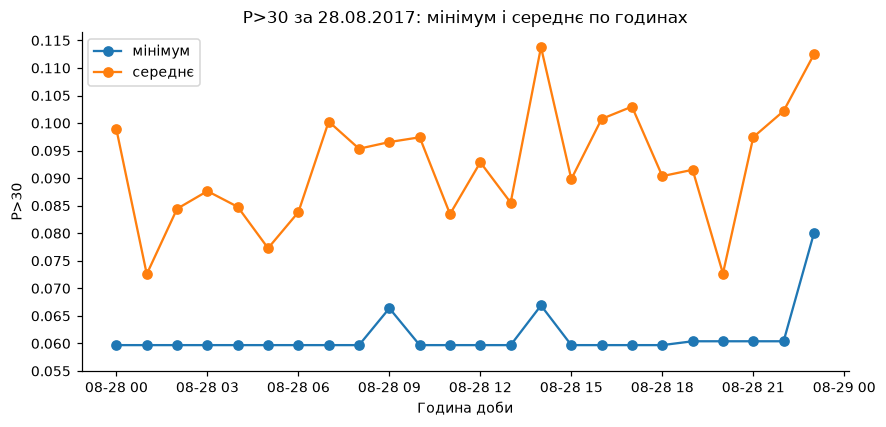

In [25]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(p30_min.index, p30_min.values, label='мінімум', marker='o')
ax.plot(p30_mean.index, p30_mean.values, label='середнє', marker='o')
ax.set_xlabel('Година доби')
ax.set_ylabel('P>30')
ax.set_yticks(np.arange(0.055, 0.12, 0.005))
ax.set_title('P>30 за 28.08.2017: мінімум і середнє по годинах')
ax.legend()
plt.show()

**Відповідь 4.2:**: на графіках можна побачити порівняння мінімуму та середнього по годинах для p>30. Крива мінімуму логічно знаходить нижче ніж крива середнього. Мінімум майже весь день тримається на рівні 0.6, на відміну від середнього, котре щогодини змінює значення. 

Різниця між показниками особливо суттєва тоді, коли протягом години трапляється короткочасний сплеск, тобто середнє збільшується, а мінімум майже не змінюється. Отже, середнє характеризує загальний рівень потоку за годину, а мінімум показує його найнижчий рівень і допомагає зрозуміти, чи було підвищення стабільним протягом усієї години.

### Завдання 4.3
Об'єднайте три таблиці в одну — назвіть її `M`. Виведіть її розмір і всі рядки,
у яких є хоча б один пропуск.

**Зверніть увагу:** таблиці закінчуються не в один і той самий момент. Тому результат
залежить від того, який тип об'єднання ви оберете (`how='inner'` чи `how='outer'`).
Спробуйте обидва, подивіться, чим відрізняється кількість рядків, і поясніть свій вибір.

In [26]:
A = A.reset_index()

A.columns = [
    col[0] if col[1] == '' else f'{col[0]}_{col[1]}'
    for col in A.columns
]

In [27]:
M = A.merge(B, how='outer', on='ts')
M = M.merge(C, how='outer', on='ts')

print(f"M розмір: {M.shape}")
print(f"Рядки в яких є хочаб один пропуск: \n{M[M.isna().any(axis=1)].shape}")

M розмір: (601, 24)
Рядки в яких є хочаб один пропуск: 
(576, 24)


Припущення: якщо внутрішньо мерждити таблиці, то розмір має бути (601-576=25, 24)

In [28]:
M_inner = A.merge(B, how='inner', on='ts')
M_inner = M_inner.merge(C, how='inner', on='ts')

print(f"M розмір: {M_inner.shape}")
print(f"Рядки в яких є хочаб один пропуск: \n{M_inner[M_inner.isna().any(axis=1)].shape}")

M розмір: (25, 24)
Рядки в яких є хочаб один пропуск: 
(0, 24)


**Відповідь 4.3:** обрано тип об'єднання 'outer' за стовпцем 'ts'. Такий тип об'єднання зберігає всі значення ts, які є хоча б в одній із таблиць. Розмір такої таблиці (601, 24).

Якщо ж спробувати інший тип об'єднання - inner, то він змерджає лише ті рядки, у яких по колонці ts є точний збіг. Саме тому розмір набагато менший (25, 24). В такій табличці нема жодних nan.

### Завдання 4.4 — поділ на групи
Щоб далі було що з чим порівнювати, поділіть години на три групи за значенням
**максимуму потоку P>10 за годину**:

| Група | Умова |
|---|---|
| `тиха` | менше 10 |
| `активна` | від 10 до 1000 |
| `дуже активна` | 1000 і більше |

Додайте до `M` стовпець `група` і виведіть, скільки годин потрапило в кожну.

> Це не вигадані числа: саме такі пороги використовує метеослужба космічної погоди
> NOAA. Чому вони саме такі — питання не сьогоднішньої роботи.

In [29]:
M['група'] = pd.cut(
    M['P>10_max'],
    bins=[-np.inf, 10, 1000, np.inf],
    labels=['тиха', 'активна', 'дуже активна']
)

print(M['група'].value_counts())

група
тиха            411
активна         171
дуже активна     18
Name: count, dtype: int64


**Самоперевірка етапу 4.**

In [30]:
assert M is not None, 'таблиця M не побудована'
assert 'ts' in M.columns, 'у таблиці M потрібен стовпець ts'
assert 'група' in M.columns, 'у таблиці M потрібен стовпець «група»'
assert 590 <= len(M) <= 605, 'очікується близько 600 рядків, а є %d — перевірте об’єднання' % len(M)
print('Етап 4 пройдено:', len(M), 'рядків')

Етап 4 пройдено: 601 рядків


---
# Етап 5. П'ять графіків — п'ять питань

Графік будується як **відповідь на питання**, а не «щоб був».

**Вимоги до кожного графіка:**

* підписані обидві осі, з одиницями вимірювання;
* заголовок;
* під графіком, у текстовій клітинці, — **одне речення про дані**.
  Не «на графіку зображено потік протонів», а твердження на кшталт
  «більшість годин потік не перевищує 60, але кілька годин дають значення у сотні разів більші».

> Не кожне питання має відповідь «так, зв'язок є». Якщо на графіку нічого не видно —
> так і напишіть. Відсутність зв'язку — це теж результат, і чесно про неї написати
> важливіше, ніж підбирати ракурс, у якому «щось наче проглядається».

### Графік 1. Як розподілені значення вашого потоку?
Побудуйте гістограму вашого потоку (середнє за годину). Порахуйте окремо середнє
й медіану цього стовпця.

Якщо гістограма вийде нечитабельною — стовпчик біля нуля і порожньо далі — не
залишайте так. Спробуйте побудувати гістограму від логарифма значень
(`np.log10`) і подивіться, що зміниться.

**Питання:** чому середнє й медіана так сильно відрізняються?

In [31]:
потік = M['P>30_mean']

середнє = потік.mean()
медіана = потік.median()

print(f"Середнє: {середнє}")
print(f"Медіана: {медіана}")


Середнє: 18.831272835858584
Медіана: 0.137825


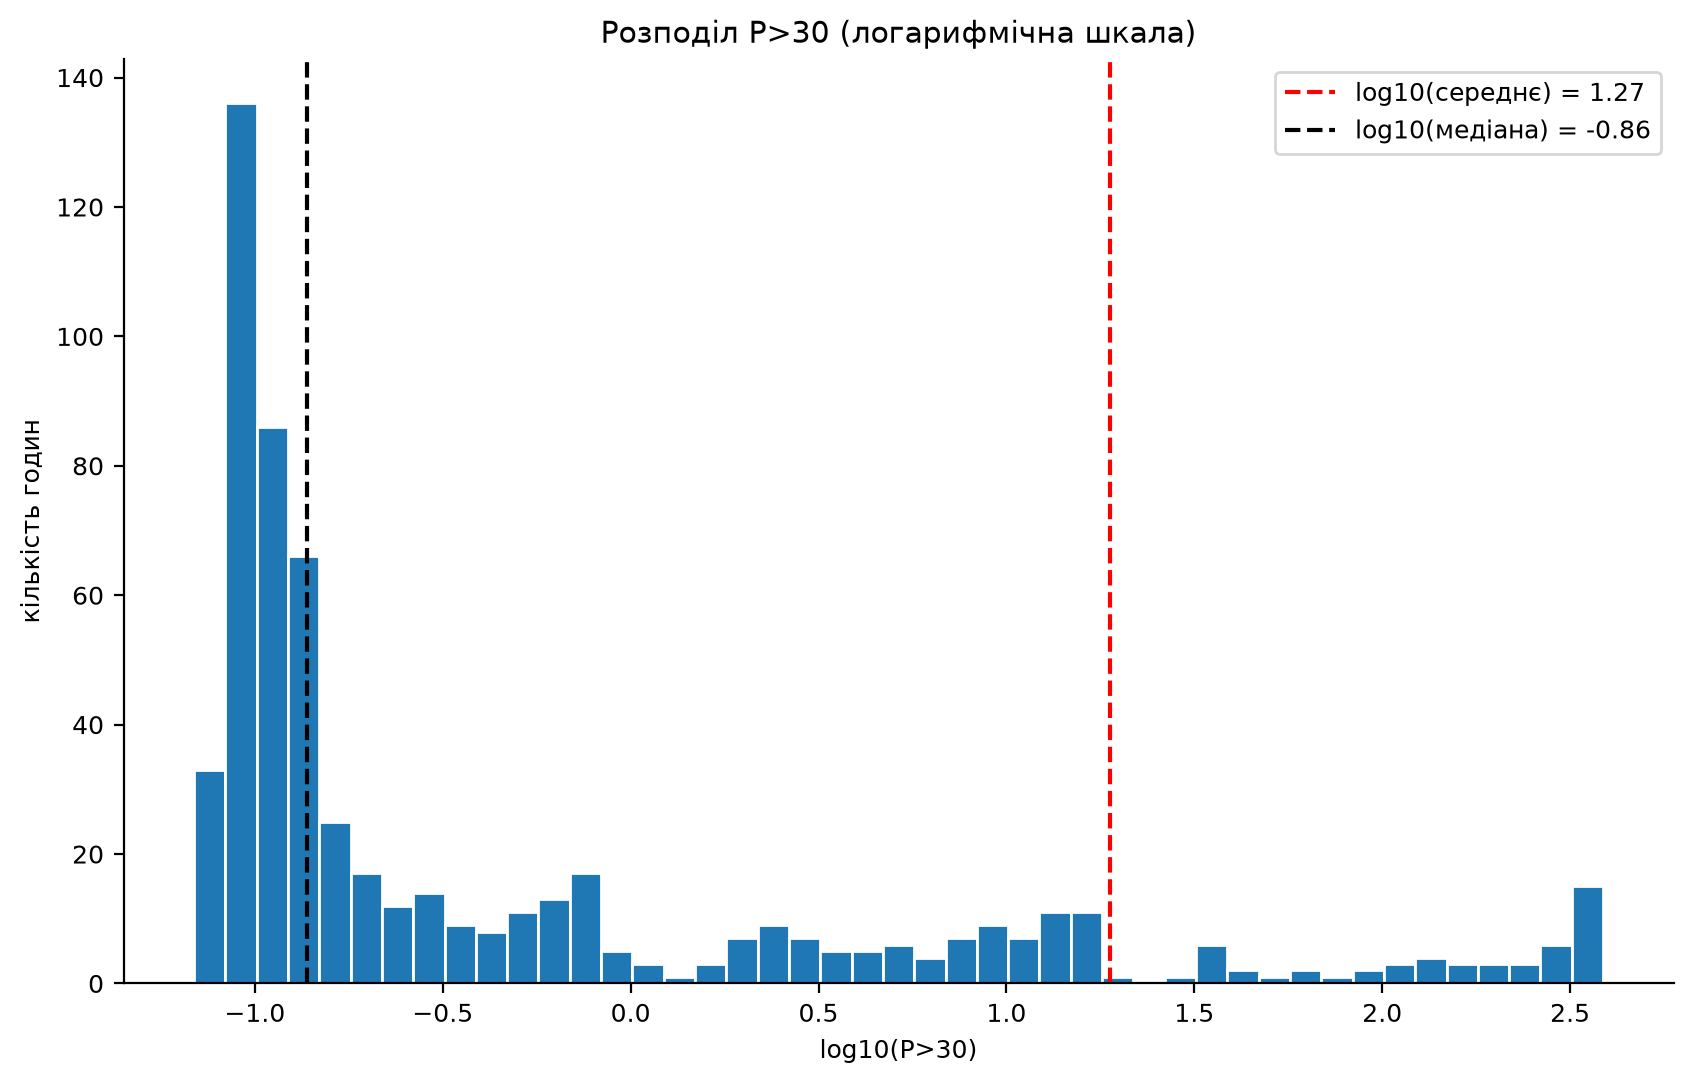

In [32]:
log_data = np.log10(потік)

fig, ax = plt.subplots(figsize=(10, 6), dpi=200)
ax.hist(log_data.dropna(), bins=45, edgecolor='white')
ax.axvline(np.log10(середнє), color='red', linestyle='--', label=f'log10(середнє) = {np.log10(середнє):.2f}')
ax.axvline(np.log10(медіана), color='black', linestyle='--', label=f'log10(медіана) = {np.log10(медіана):.2f}')
ax.set_xlabel('log10(P>30)')
ax.set_ylabel('кількість годин')
ax.set_title('Розподіл P>30 (логарифмічна шкала)')
ax.legend()

**Висновок:** причиною того, що медіана та середнє сильно відрізняються є той факт, що у графіка сильно виражена правостороння асиметрія, більшість значень дуже близькі до нуля. Середнє знаходиться більш "правіше", оскільки середнє значення є чутливим до екстримальних значень, тоді як медіана їх ігнорує. 
Тому після перетворення за логарифмом розподіл став більш читабельним, і видно, що більшість годин лежить у вузькому діапазоні низьких значень.

### Графік 2. Чи відрізняється швидкість вітру між групами годин?
Побудуйте діаграму розмаху (`boxplot`) швидкості сонячного вітру окремо для кожної
групи з завдання 4.4.

Text(0.5, 1.0, 'Швидкість сонячного вітру за групами активності')

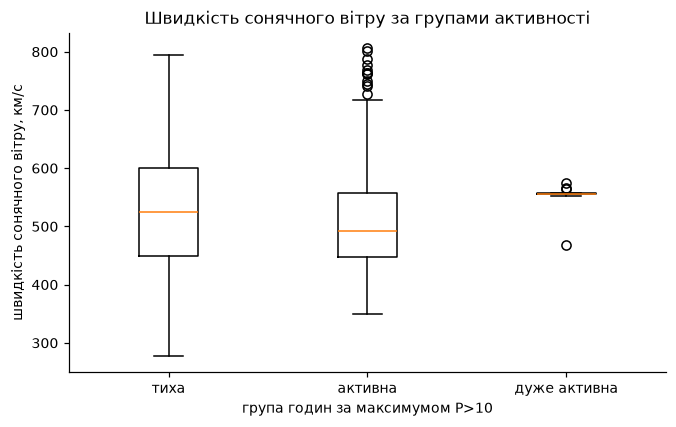

In [33]:
groups = ['тиха', 'активна', 'дуже активна']
boxplot_data = [M.loc[M['група'] == group, 'SPEED'].dropna() for group in groups]

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot(boxplot_data, tick_labels=groups)
ax.set_xlabel('група годин за максимумом P>10')
ax.set_ylabel('швидкість сонячного вітру, км/с')
ax.set_title('Швидкість сонячного вітру за групами активності')


**Висновок:** з графіка можна побачити, що медіани швидкості для усіх трьох груп знаходяться в межах 450-550 км/с, проте видимої залежності швидкості вітру від інтенсивності потоку P>10 у цих даних не видно. Одне із можливих пояснень такої поведінки це те що потік енергетичних частинок і сонячний вітер це різні за походженням процеси, і частинки долітають до Землі набагато швидше за вітер.

### Графік 3. Чи пов'язані змінні вашої пари?
Побудуйте діаграму розсіювання для пари з вашого завдання. Порахуйте коефіцієнт
кореляції між ними.

Text(0.5, 1.0, 'Густина вітру та потік P>1')

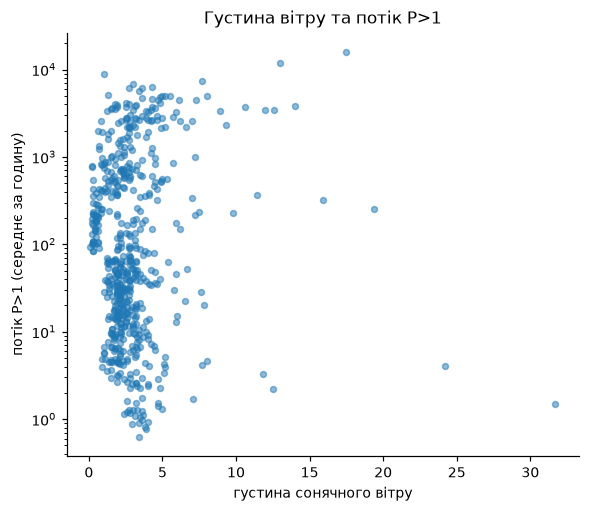

In [34]:
x, y = M['DENSITY'], M['P>1_mean']

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(x, y, alpha=0.5, s=15)
ax.set_yscale('log')
ax.set_xlabel('густина сонячного вітру')
ax.set_ylabel('потік P>1 (середнє за годину)')
ax.set_title('Густина вітру та потік P>1')


In [35]:
corr_coef = M[['DENSITY', 'P>1_mean']].corr().iloc[0, 1]
print(f"Коефіцієнт кореляції: {corr_coef}")

Коефіцієнт кореляції: 0.28528892999766564


**Висновок:** значення коефіцієнта кореляції = 0.29 є доволі низьким, що свідчить про відсутність залежності між густиною вітру та потоком P1.
Це підтверджується і графіком: переважна більшість точок сконцентрована в дуже вузькому діапазоні густини і при цьому охоплює майже весь діапазон значень потоку P>1. Тобто при практично однаковій густині вітру потік частинок може відрізнятися на 3–4 порядки.

### Графік 4. Скільки годин у кожній групі?
Побудуйте стовпчикову діаграму кількості годин за групами. Підпишіть кожен стовпчик
кількістю годин і відсотком від загальної кількості.

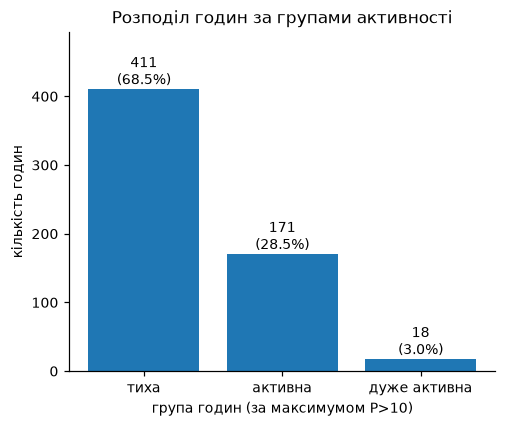

In [36]:
group_value_counts = M['група'].value_counts()
total = group_value_counts.sum()

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(groups, group_value_counts.values)

for bar, count in zip(bars, group_value_counts.values):
    percent = count / total * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{count}\n({percent:.1f}%)',
        ha='center', va='bottom'
    )

ax.set_xlabel('група годин (за максимумом P>10)')
ax.set_ylabel('кількість годин')
ax.set_title('Розподіл годин за групами активності')
ax.set_ylim(0, group_value_counts.max() * 1.2);

**Висновок:** з графіка можна побачити, що переважну більшість годин переважала група "тиха" - 68.5%. Активна - 28.5%, та дуже активна - 3%. Можна зробити з цього висновок, що дуже екстремальні спалахи потоку P>10 це рідкісна подія. Більшість часу космічна погода в цьому вікні спостережень залишалася спокійною.

### Графік 5. Як усе це виглядало в часі?
Побудуйте лінійний графік максимуму потоку P>10 за годину за весь період спостережень.

Якщо крива виявиться нечитабельною — згадайте, що допомогло в графіку 1.

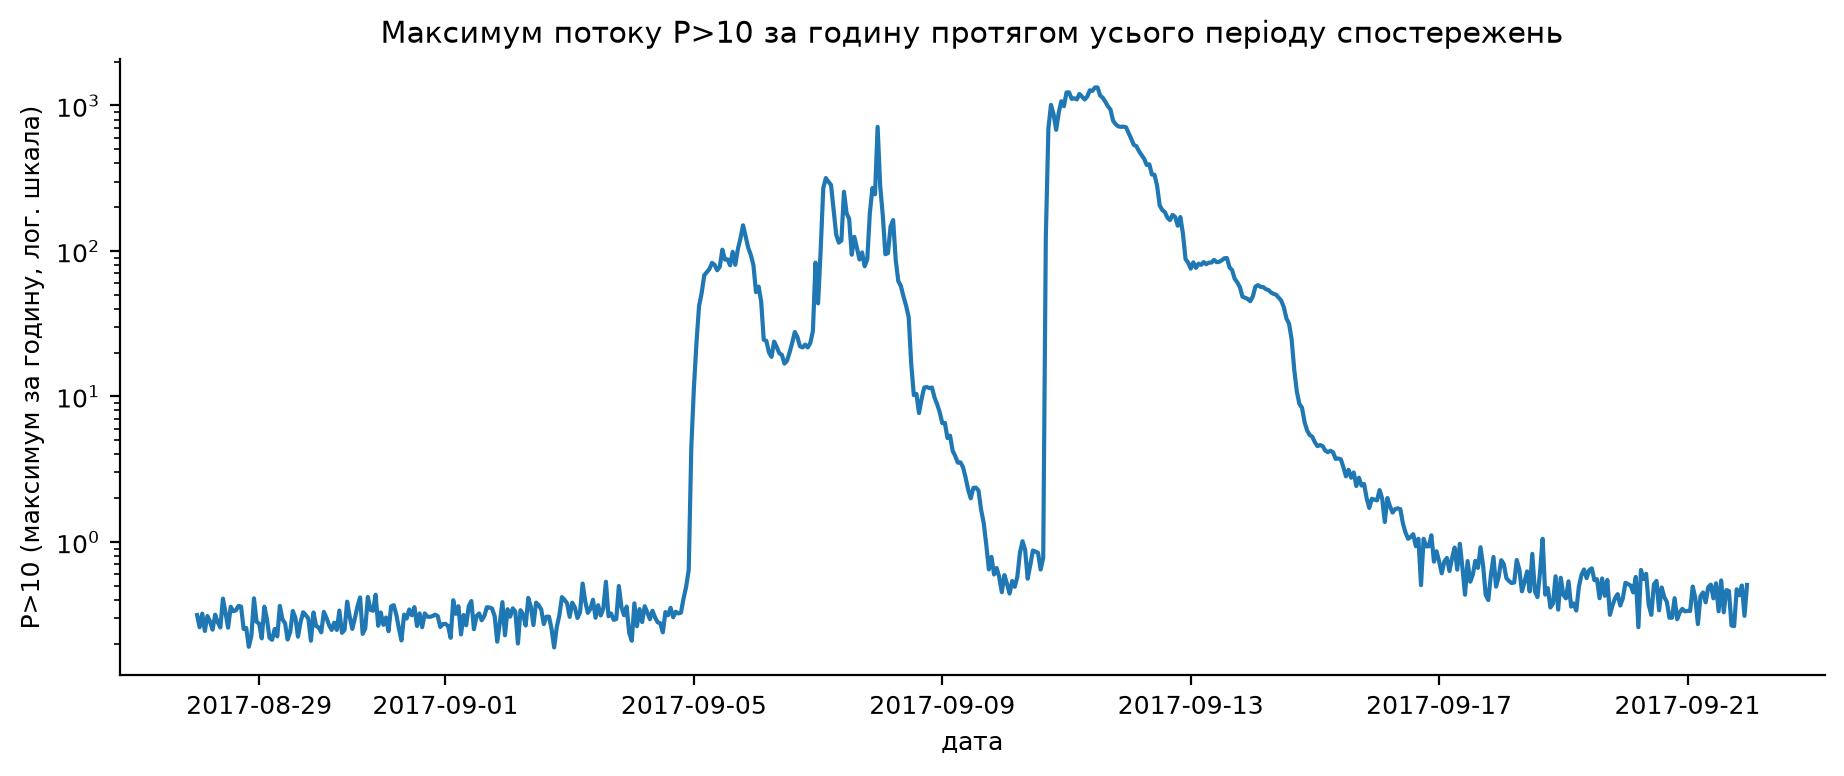

In [37]:
fig, ax = plt.subplots(figsize=(11, 4), dpi=200)
ax.plot(M['ts'], M['P>10_max'])
ax.set_yscale('log')
ax.set_xlabel('дата')
ax.set_ylabel('P>10 (максимум за годину, лог. шкала)')
ax.set_title('Максимум потоку P>10 за годину протягом усього періоду спостережень');

**Висновок:** з графіка можна побачити три досить чіткі спалахи активності, які відбувались у період з 5 по 17 вересня 2017 року. Після кожного спалаху потік поступово спадає протягом кількох діб. Після 17 вересня потік повернувся до вихідного фонового значення. Найпотужніший пік відбувся 11–12 вересня.

---
# Етап 6. Два графіки одних і тих самих даних

Нижче побудовано два графіки. Дані в них **одні й ті самі** — це той самий стовпець
з тієї самої таблиці, жодне число не змінено.

Виконайте клітинку й подивіться на обидва.

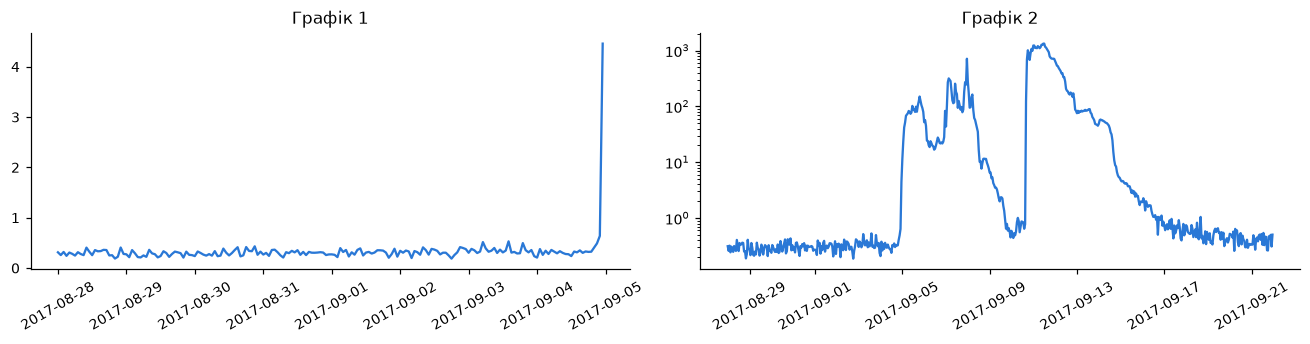

In [44]:
СТОВПЕЦЬ = 'P>10_max'   

вікно = M[(M['ts'] >= '2017-08-28') & (M['ts'] < '2017-09-05')]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))

ax[0].plot(вікно['ts'], вікно[СТОВПЕЦЬ], color='#2a78d6')
ax[0].set_title('Графік 1')
ax[0].tick_params(axis='x', rotation=30)

ax[1].plot(M['ts'], M[СТОВПЕЦЬ], color='#2a78d6')
ax[1].set_yscale('log')
ax[1].set_title('Графік 2')
ax[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

### Завдання 6.1
Дайте відповідь на три питання:

1. Який висновок про космічну погоду у вересні 2017 року зробить людина, яка бачила
   **тільки перший** графік?
2. Який висновок зробить людина, яка бачила **тільки другий**?
3. Чим ці два графіки відрізняються між собою? Назвіть **дві** відмінності —
   вони обидві є в коді вище.

*Жодне число в обох графіках не підроблене. Різниця виникла тільки через те,
як їх побудували.*

**Відповідь 6.1:**

1. Висновок з першого графіка: можна зробити висновок, що протягом більшої частини тижня погода була стабільною, за вийнятком 5 вересня - тут графік показує різкий стрибок. Оцінювати космічну погоду у вересні лише за одним тижднем є поганою практикою.
2. Висновок з другого графіка: другий графік дозволяє нам побачити цілу картину та зробити правдивий висновок про прогоду протягом усього місяця. Можна побачити три спалахи активності, які відбувались у період з 5 по 17 вересня. 
3. Дві відмінності між ними: 

1. Часовий діапазон: перший графік охоплює лише коротке "вікно" з 28 серпня по 5 вересня, а другий весь період спостережень починаючи з 28 серпня, закінчуючи 22 вересня.
2. Другий графік, на відміну від першого, побудований у логарифмічній шкалі, що дозволяє детальніше побачити як і фоновий рівень, так і піки активності.


### Завдання 6.2
Уявіть, що вам потрібно **одним графіком** чесно показати, що відбувалося в цьому
періоді. Побудуйте його самі й підпишіть заголовком, який формулює висновок.

Поясніть у клітинці нижче, чому ви обрали саме такий вигляд.

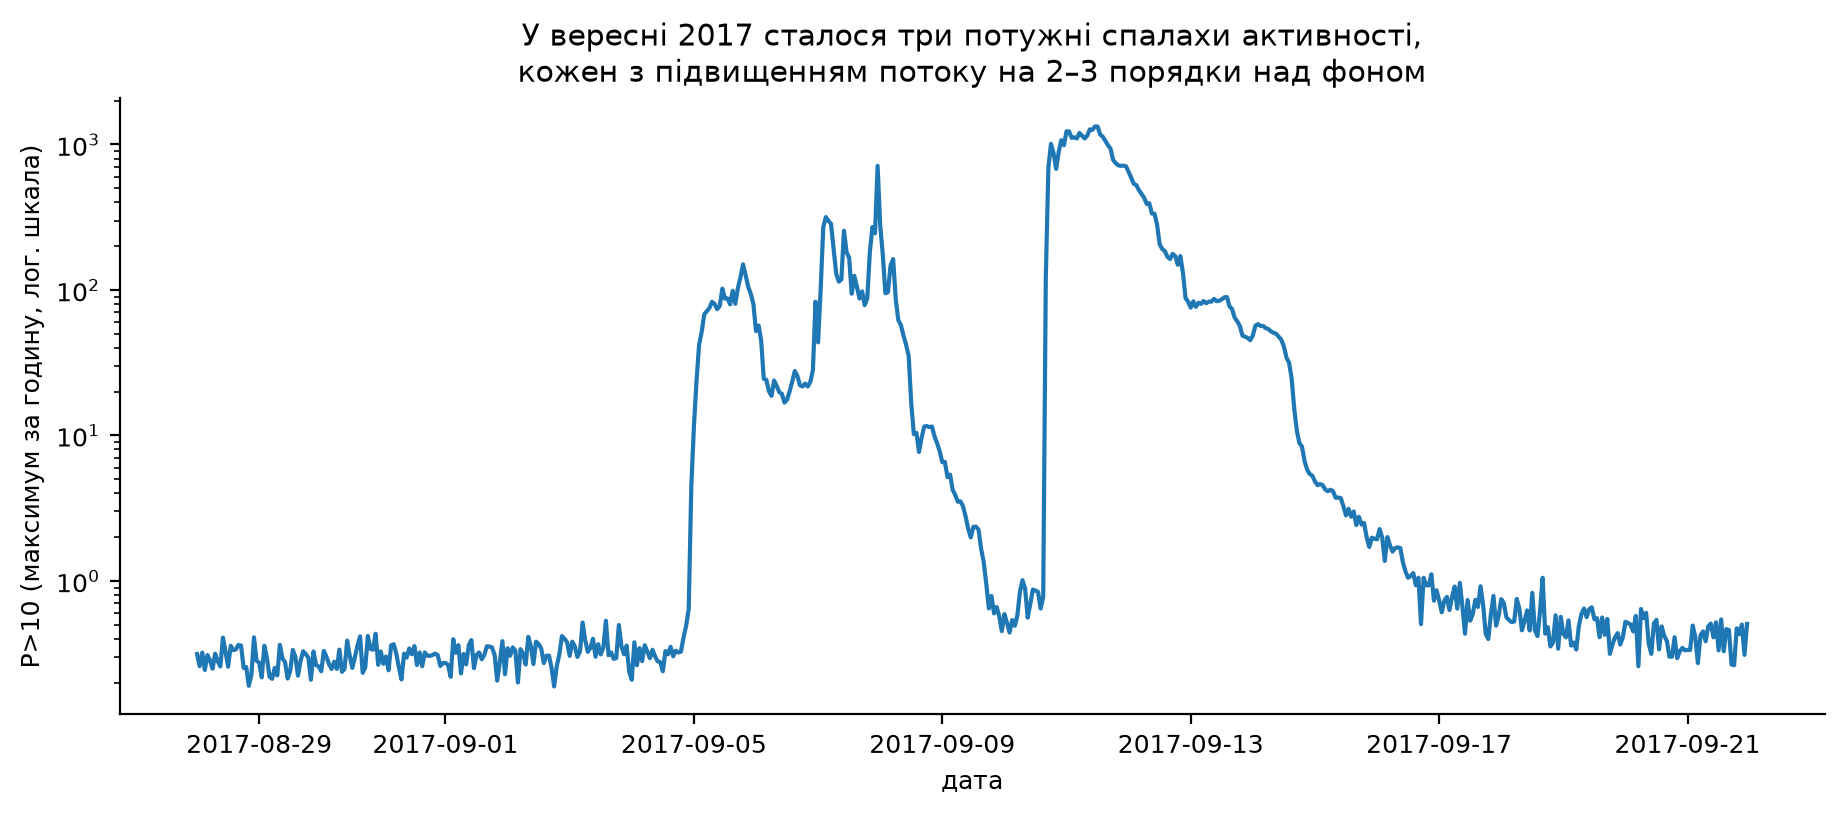

In [53]:
fig, ax = plt.subplots(figsize=(11, 4), dpi=200)
ax.plot(M['ts'], M['P>10_max'])
ax.set_yscale('log')
ax.set_xlabel('дата')
ax.set_ylabel('P>10 (максимум за годину, лог. шкала)')
ax.set_title('У вересні 2017 сталося три потужні спалахи активності,\nкожен з підвищенням потоку на 2–3 порядки над фоном');

**Відповідь 6.2:** саме такий вигляд дозволяє побачити усю активність протягом місяця, а не лише за один тиждень, включно з фоновим рівнем потоку і спалахами активності. Якщо ж обрати лінійну шкалу, то вона несе меншу кількість інформації, оскільки малі значення поглинаються великими.  

---
# Етап 7. Три спостереження та ваше питання

### Завдання 7.1
Запишіть **три спостереження** про ці дані, які ви зробили під час роботи.

Спостереження — це твердження, яке спирається на конкретне число або графік з вашого
ноутбука. Не «дані цікаві», а, наприклад, «максимальне значення потоку у 2000 разів
більше за медіанне, і всі такі години припадають на одні й ті самі три доби».

Для кожного вкажіть, **де саме** у вашій роботі його видно.

**Спостереження 1:**  (з 4 графіка 5 етапу, а також завдання 6.2) можна спостерігати нерівномірний розподіл годин за групами активності. 68.5% годин належать до "тихої" групи, 28.5% - до "активної" і лише 3.0% - до "дуже активної". Ці 18 годин (3% від загальної кількості) відповідають трьом коротким, але потужним спалахам потоку P>10, найсильніший з яких (11–12 вересня) підіймає потік до значення в околі 1300.

**Спостереження 2:** (завдання 3.2) у таблиці C було виявлено 8 рядків із фізично неможливими від'ємними значеннями швидкості та густини сонячного вітру, які згідно зі службовим описом файлу позначають пропущені дані. Після заміни на nan мінімум швидкості змінився з -1 до 277.0, а мінімум густини з -1 до 0.1.

**Спостереження 3:** (завдання 4.2) протягом доби (за 28.08.2017) мінімум потоку P>30 залишався майже незмінним на рівні 0.06, тоді як середнє коливалось набагато сильніше (від 0.073 до 0.114). Різниця між кривими стала особливо помітною в години короткочасних піків, наприклад, о 08-28 14, коли середнє сягає 0.114 при мінімумі 0.067, а також і наприкінці доби, о 08-28 23. Це показує, що мінімум характеризує найспокійніший момент години і майже не реагує на короткочасні коливання, тоді як середнє чутливіше до будь-яких стрибків усередині години і краще відображає загальний рівень активності.


### Завдання 7.2 — ваше індивідуальне питання
Дайте відповідь на додаткове питання зі свого завдання. Відповідь має спиратися
на обчислення: наведіть код і результат, а потім сформулюйте висновок словами.

Питання: У яку добу середнє значення вашого потоку (p>30) було найбільшим? А найменшим?

In [60]:
day_average = M.set_index('ts')['P>30_mean'].resample('D').mean()

day_max_average = day_average.idxmax()
day_min_average = day_average.idxmin()

print(f"Найбільше середнє добове значення P>30: {day_average.max():.4f}, дата: {day_max_average.date()}")
print(f"Найменше середнє добове значення P>30: {day_average.min():.4f}, дата: {day_min_average.date()}")

Найбільше середнє добове значення P>30: 292.9306, дата: 2017-09-11
Найменше середнє добове значення P>30: 0.0897, дата: 2017-09-01


**Відповідь 7.2:** найбільше середнє добове значення потоку P>30 спостерігалося 11 вересня 2017 року і становило приблизно 292.93 (збігається з найпотужнішим із трьох спалахів активності (графік 5)). Найменше середнє добове значення зафіксовано 1 вересня 2017 року і становило приблизно 0.09. Максимальне більше за мінімальне добове середнє приблизно у 3255 разів, що ще раз підтверджує сильно нерівномірний характер активності потоку P>30 протягом усього періоду спостережень.

---
# Етап 8. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями під час виконання цієї роботи **дозволено**. Це
нормальна інженерна практика, і курс про штучний інтелект не має підстав її забороняти.

Обов'язковою є прозорість: ви вказуєте, де саме і як скористалися інструментом —
так само, як у науковій статті вказують використане програмне забезпечення.
**Задекларована допомога порушенням не є.**

Порушенням є інше: здати роботу, яку ви не можете пояснити. На захисті вас попросять
показати конкретний рядок вашого коду, пояснити, чому він саме такий, і внести в нього
невелику зміну на місці. Якщо код згенеровано, але ви його розумієте — робота
зарахована. Якщо не розумієте — не зарахована, незалежно від того, хто його написав.

### Завдання 8.1
Заповніть словник. Для кожного етапу оберіть одне з формулювань:

* `'ні'` — інструментами ШІ не користувався;
* `'синтаксис'` — питав про назву функції або синтаксис, код писав сам;
* `'код, перевірено'` — код згенеровано, я його прочитав, перевірив і розумію;
* `'текст, перероблено'` — згенеровано чернетку тексту, яку я переписав по суті;
* `'текст, як є'` — згенерований текст залишено майже без змін.

Останній варіант не заборонений, але прямо впливає на оцінку: бали ставляться
за висновки, а не за наявність абзацу.

In [67]:
ІНСТРУМЕНТИ_ШІ = 'Claude'


ДЕКЛАРАЦІЯ = {
    'етапи 1–2, читання файлу та розбір таблиць': 'ні',
    'етап 3, паспорт даних і дивні значення':     'синтаксис',
    'етап 4, об’єднання таблиць':                 'синтаксис',
    'етап 5, побудова графіків':                  'код, перевірено',
    'етап 5, формулювання висновків':             'текст, перероблено',
    'етапи 6–7, порівняння графіків і спостереження': 'текст, перероблено',
}

ЩО_ПЕРЕВІРЕНО = 'інколи просила визначити чому код не працює, в більшості були проблеми із синтаксисом пандас, ' \
'також ші допомагав мені з побудовою графіків, доповнював мої висновки + пояснював фізичну природу явищ'

ПІДТВЕРДЖУЮ = True

In [68]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}

assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено пункти декларації: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s. Оберіть з переліку вище.' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше, що саме ви перевірили '
                                           '(зараз %d символів, потрібно щонайменше 120)'
                                           % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'

print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-46s %s' % ('автор:', ПІБ))
print('%-46s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-46s %s' % (k + ':', v))
print('-' * 78)
print('перевірено автором:')
print(ЩО_ПЕРЕВІРЕНО)
print('=' * 78)
print('Автор підтверджує, що може пояснити кожен рядок коду під час захисту.')

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                         Костак Олеся
інструменти:                                   Claude
------------------------------------------------------------------------------
етапи 1–2, читання файлу та розбір таблиць:    ні
етап 3, паспорт даних і дивні значення:        синтаксис
етап 4, об’єднання таблиць:                    синтаксис
етап 5, побудова графіків:                     код, перевірено
етап 5, формулювання висновків:                текст, перероблено
етапи 6–7, порівняння графіків і спостереження: текст, перероблено
------------------------------------------------------------------------------
перевірено автором:
інколи просила визначити чому код не працює, в більшості були проблеми із синтаксисом пандас, також ші допомагав мені з побудовою графіків, доповнював мої висновки + пояснював фізичну природу явищ
Автор підтверджує, що може пояснити кожен рядок коду під час захисту.


---
# Крок 9. Збереження результату та фінальна самоперевірка

Об'єднана таблиця знадобиться вам у лабораторних роботах № 3 і № 4 — збережіть її
й не втрачайте до кінця семестру.

In [69]:
M.to_csv('master_hourly.csv', index=False)
print('збережено:', M.shape)

збережено: (601, 25)


In [70]:
# --- фінальна самоперевірка --------------------------------------------------
перевірки = {
    'ПІБ і варіант заповнено':        bool(ПІБ) and bool(ВАРІАНТ),
    'таблиця A (7200 рядків)':        len(A) == 7200,
    'таблиця B (25 рядків)':          len(B) == 25,
    'таблиця C (601 рядок)':          len(C) == 601,
    'таблиці об’єднано':              M is not None and 590 <= len(M) <= 605,
    'стовпець «група» є':             'група' in M.columns,
    'усі дати у 2017 році':           int(pd.to_datetime(M['ts']).dt.year.min()) == 2017,
    'декларацію заповнено':           bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)

if all(перевірки.values()):
    print('\nТехнічна частина роботи виконана.')
    print('Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
НЕ ОК  таблиця A (7200 рядків)
OK     таблиця B (25 рядків)
OK     таблиця C (601 рядок)
OK     таблиці об’єднано
OK     стовпець «група» є
OK     усі дати у 2017 році
OK     декларацію заповнено
